# Skórovací karta úvěrového rizika s rozhodovacím stromem (PROC HPSPLIT)

## Shrnutí

Tento sešit sestavuje srozumitelnou skórovací kartu úvěrového selhání pro portfolio spotřebitelských úvěrů pomocí PROC HPSPLIT. Vypěstujeme klasifikační strom s kritériem entropie na syntetických datech žadatelů, prořežeme ho nákladovou komplexitou a poté si přečteme statistiky shody, důležitost proměnných, ROC/AUC a samotný skórovací strom — přesně ten transparentní, pro regulátora srozumitelný model, který by rizikový tým banky zdokumentoval. Každého žadatele lze ohodnotit do listu a celý strom lze exportovat jako nasaditelný kód kroku DATA.

## Zdroje dat

| Datová sada | Řádky | Popis | Klíčové proměnné |
|---------|------|-------------|---------------|
| `applicants` | 100 | Syntetičtí žadatelé o spotřebitelský úvěr generovaní přímo pomocí `rand()`. Binární příznak `default` je vylosován z logistického rizikového skóre tak, aby horší DTI, vyšší využití úvěru, nedávná opoždění splátek a kratší úvěrová historie zvyšovaly pravděpodobnost selhání. | `default` (událost=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

Krok DATA požaduje větší smyčku, ale toto prostředí běží v nelicencovaném režimu a materializuje prvních 100 pozorování — kompaktní, plně reprodukovatelnou knihu žadatelů, která bohatě stačí k vypěstování a přečtení srozumitelné skórovací karty.

# Skórovací karta úvěrového rizika s rozhodovacím stromem

Banky potřebují modely selhání, které jsou **přesné a vysvětlitelné** — úvěrový referent (a regulátor) musí umět přesně vystopovat, proč byl žadatel ohodnocen jako vysoce rizikový. Prořezaný rozhodovací strom to umožňuje: každá predikce je krátký řetězec srozumitelných rozhodovacích pravidel.

V tomto sešitu:

1. Vygenerujeme syntetickou knihu žádostí o spotřebitelský úvěr.
2. Vypěstujeme klasifikační strom pomocí `PROC HPSPLIT` s kritériem entropie.
3. Prořežeme ho nákladovou komplexitou, abychom se vyhnuli přeučení.
4. Prozkoumáme statistiky shody, důležitost proměnných, ROC/AUC a samotný strom.
5. Vygenerujeme skórovací kód v kroku DATA, který lze nasadit proti novým žádostem.

## 1. Vygenerování syntetické knihy úvěrů

Vygenerujeme žadatele, jejichž pravděpodobnost selhání je logistickou funkcí klasických faktorů skórovací karty: poměr dluhu k příjmu, využití revolvingového úvěru, FICO skóre, délka úvěrové historie a nedávná opoždění splátek. Poté vylosujeme pozorovaný příznak `default` z Bernoulliho rozdělení s touto pravděpodobností, takže signál je skutečný, ale zašuměný — přesně jako produkční data. Zde je materializováno prvních 100 žadatelů.

                                                   The FREQ Procedure

Selhání splátek       Frequency    Percent
-------------------------------------------
0                            79     79.00
1                            21     21.00

Bydlení      Frequency    Percent
----------------------------------
hypotéka            34     34.00
nájem               35     35.00
vlastní             31     31.00

Účel úvěru        Frequency    Percent
---------------------------------------
auto                     23     23.00
bydlení                  28     28.00
dluh                     37     37.00
jiné                     12     12.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


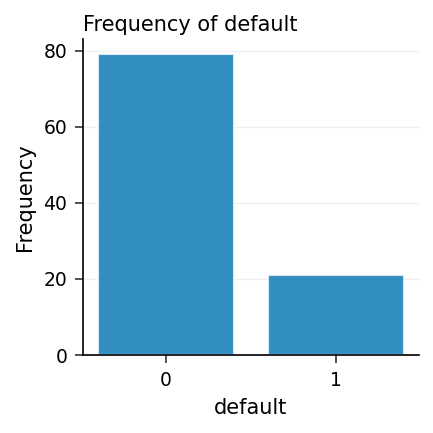

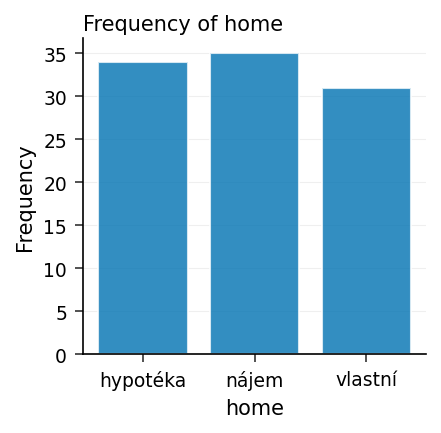

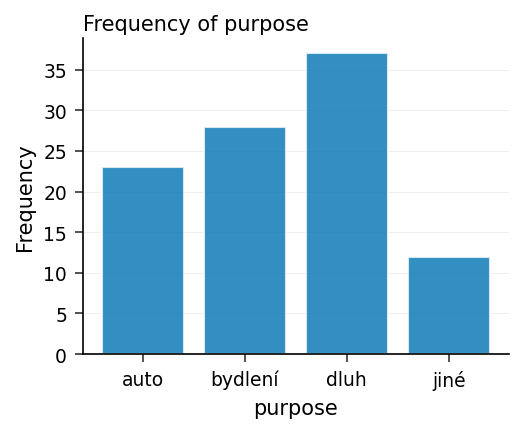

In [1]:
data applicants;
   CALL streaminit(20260531);
   DÉLKA home $16 purpose $12;
   OPAKUJ id = 1 TO 100;
      /* Finanční profil žadatele */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Kategoriální atributy */
      u = rand('uniform');
      KDYŽ u < 0.34 PAK home = 'nájem';
      JINAK KDYŽ u < 0.70 PAK home = 'hypotéka';
      JINAK home = 'vlastní';

      v = rand('uniform');
      KDYŽ v < 0.40 PAK purpose = 'dluh';
      JINAK KDYŽ v < 0.65 PAK purpose = 'bydlení';
      JINAK KDYŽ v < 0.85 PAK purpose = 'auto';
      JINAK purpose = 'jiné';

      /* Latentní riziko selhání: horší DTI/využití/opoždění a
         nižší FICO / kratší historie zvyšují logit. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'nájem')
            + 0.25 * (purpose = 'dluh');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      ODSTRANIT u v eta p;
      VÝSTUP;
   KONEC;
   ŠTÍTEK id = 'ID žadatele'
         income = 'Příjem'
         loan_amount = 'Výše úvěru'
         dti = 'Poměr dluhu k příjmu (DTI)'
         utilization = 'Využití revolvingového úvěru'
         fico = 'FICO skóre'
         credit_age = 'Délka úvěrové historie (roky)'
         n_delinq = 'Počet nedávných opoždění splátek'
         home = 'Bydlení'
         purpose = 'Účel úvěru'
         default = 'Selhání splátek';
SPUSTIT;

PROCEDURA ČETNOSTI data=applicants;
   TABLES default home purpose / nocum;
SPUSTIT;

Výstup `PROC FREQ` potvrzuje nevyváženou, ale zpracovatelnou míru selhání — selhává zhruba jeden žadatel z pěti (21 ze 100) — a rozumné rozložení kategorií bydlení a účelu úvěru: přesně takové okrajové rozdělení, jaké byste čekali ve spotřebitelském úvěrovém portfoliu. Přiložené sloupcové grafy vizualizují každé okrajové rozdělení.

## 2. Vypěstování a prořezání skórovacího stromu

Modelujeme `default` jako binární klasifikační cíl, s `event='1'`, aby všechny statistiky senzitivity/specificity/AUC byly orientovány na třídu *selhání*. Postupujeme takto:

- deklarujeme kategoriální prediktory a odezvu v `CLASS`,
- vypěstujeme strom pomocí kritéria **entropie** (informačního zisku),
- prořežeme **nákladovou komplexitou**, aby si strom nezapamatoval šum,
- požádáme o **diagram celého stromu** a **ROC křivku**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Selhání splátek
  Class variable: Selhání splátek
  Class variable: Bydlení
  Class variable: Účel úvěru
  Predictor variable: Poměr dluhu k příjmu (DTI)
  Predictor variable: Využití revolvingového úvěru
  Predictor variable: FICO skóre
  Predictor variable: Délka úvěrové historie (roky)
  Predictor variable: Počet nedávných opoždění splátek
  Predictor variable: Výše úvěru
  Predictor variable: Příjem
  Predictor variable: Bydlení
  Predictor variable: Účel úvěru

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leave


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


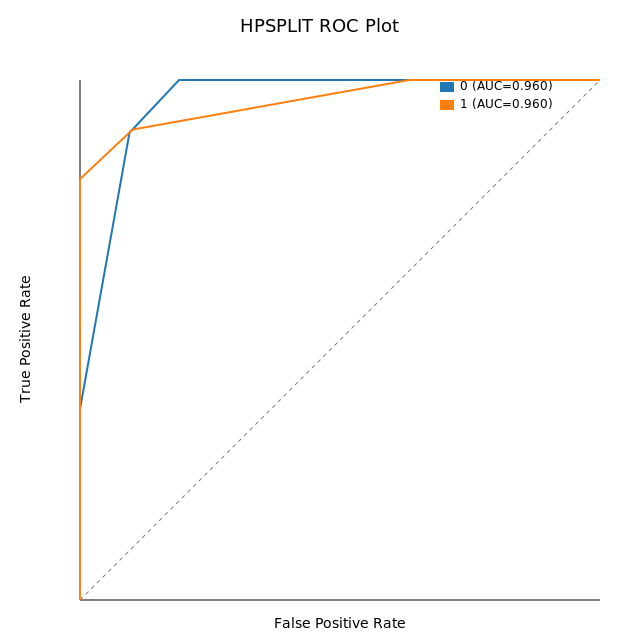

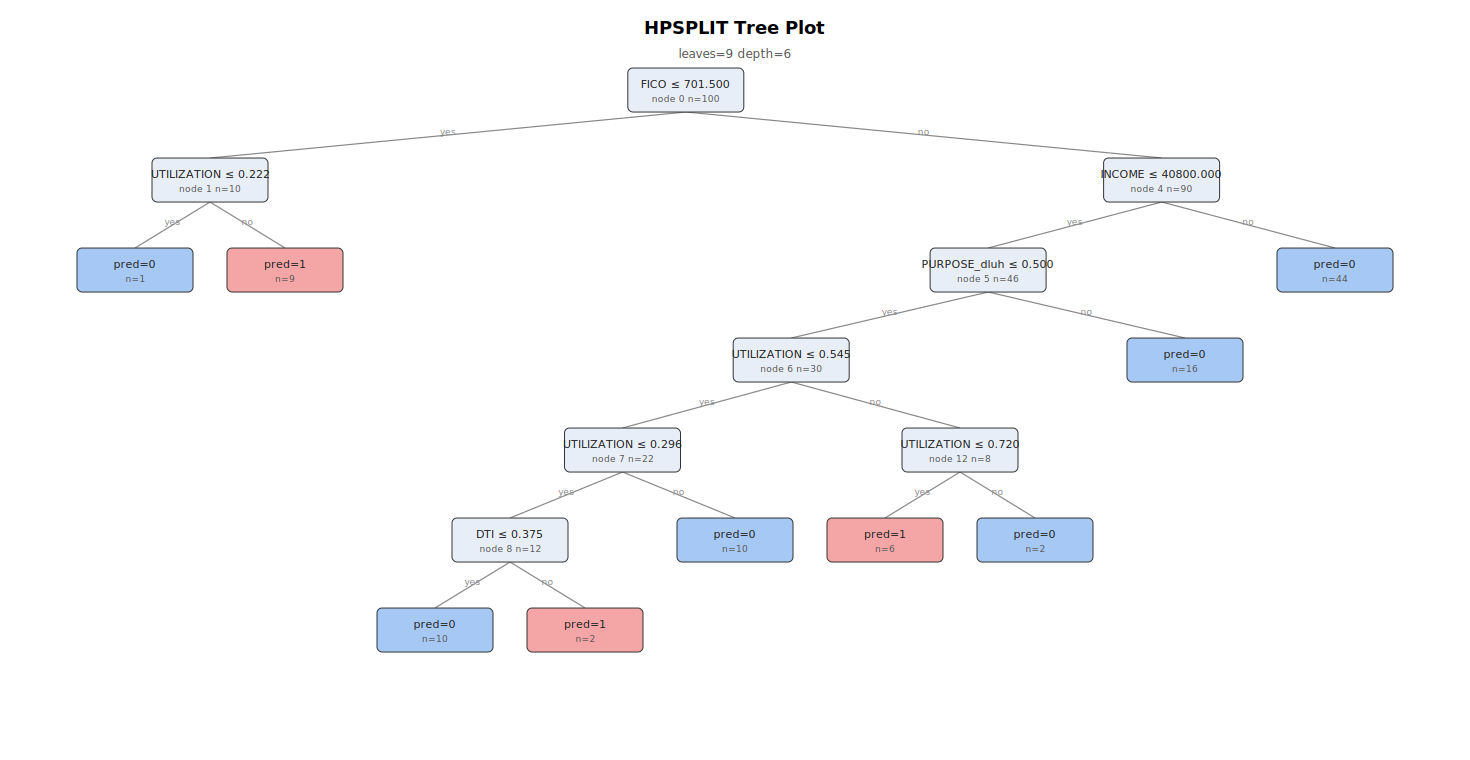

In [2]:
ODS GRAPHICS ON;

PROCEDURA hpsplit data=applicants seed=20260531
             PLOTS=(wholetree roc);
   TŘÍDA default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
SPUSTIT;

**Statistiky shody** (přesnost, míra chybné klasifikace, log loss) a **ROC / AUC podle třídy** říkají, jak čistě prořezaný strom odděluje ty, kdo selžou, od těch, kdo neselžou. Tabulka **důležitosti proměnných** řadí, které atributy nejvíce řídí rozdělení uzlů — zde dominují **využití úvěru** a **FICO skóre**, následované **účelem úvěru**, přesně ty páky, na které by se zaměřila úvěrová politika. **Graf celého stromu** níže rozkládá zvolená rozdělení jako diagram uzlů a hran: každý vnitřní uzel ukazuje pravidlo `atribut ≤ práh` a každý list je obarven podle predikované třídy (červená = predikované selhání, modrá = predikované neselhání) a popsán počtem pozorování.

## 3. Přiblížení hlavních rozdělení a ohodnocení každého žadatele

Graf ROC výše vizualizuje kompromis mezi zachycením těch, kdo selžou, a falešnými poplachy; AUC kvantifikuje celkovou rozlišovací sílu. Dále přiblížíme horní dvě úrovně stromu — rozdělení s nejvyšší informační hodnotou, která by analytik převedl na hlavní upisovací pravidla — a zachytíme skóre za jednotlivá pozorování do výstupní datové sady, abychom mohli predikce dále auditovat.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Selhání splátek
  Class variable: Selhání splátek
  Class variable: Bydlení
  Class variable: Účel úvěru
  Predictor variable: Poměr dluhu k příjmu (DTI)
  Predictor variable: Využití revolvingového úvěru
  Predictor variable: FICO skóre
  Predictor variable: Délka úvěrové historie (roky)
  Predictor variable: Počet nedávných opoždění splátek
  Predictor variable: Výše úvěru
  Predictor variable: Příjem
  Predictor variable: Bydlení
  Predictor variable: Účel úvěru

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leave


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/9589a314-eb3c-448c-b457-60fb504930af/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


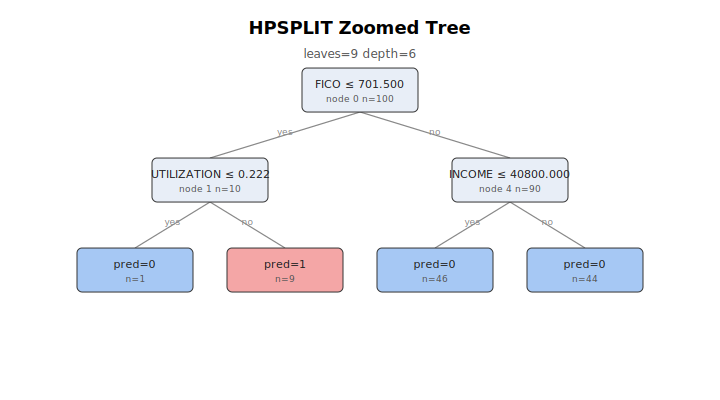

In [3]:
PROCEDURA hpsplit data=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   TŘÍDA default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   VÝSTUP out=scored;
SPUSTIT;

PROCEDURA TISK data=scored(obs=10) ŠTÍTEK;
   PROMĚNNÁ p_default1 _node_ _leaf_;
   ŠTÍTEK p_default1 = 'Predikovaná pravděpodobnost selhání'
         _node_      = 'Uzel'
         _leaf_      = 'List';
SPUSTIT;

Graf `zoomedtree` přibližuje horní dvě úrovně stromu — rozdělení s nejvyšší informační hodnotou, která by analytik převedl na hlavní upisovací pravidla. Datová sada `OUTPUT OUT=` nese pro každého žadatele predikovanou pravděpodobnost selhání (`P_DEFAULT1`) plus přiřazený uzel a list (`_NODE_`, `_LEAF_`), takže rizikový a auditní tým může vystopovat jakékoli individuální rozhodnutí zpět stromem a seřadit žadatele podle modelovaného rizika.

## 4. Export nasaditelného skórovacího kódu

Hodnota vysvětlitelného modelu je v tom, že se dá nasadit. `CODE FILE=` zapíše samostatný krok DATA — vnořený řetězec pravidel `IF/THEN` končící predikovanou pravděpodobností selhání a třídou — který reprodukuje skóre stromu pro jakýkoli nový soubor žádostí bez nutnosti modelového serveru.

In [4]:
PROCEDURA hpsplit data=applicants seed=20260531;
   TŘÍDA default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
SPUSTIT;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Selhání splátek
  Class variable: Selhání splátek
  Class variable: Bydlení
  Class variable: Účel úvěru
  Predictor variable: Poměr dluhu k příjmu (DTI)
  Predictor variable: Využití revolvingového úvěru
  Predictor variable: FICO skóre
  Predictor variable: Délka úvěrové historie (roky)
  Predictor variable: Počet nedávných opoždění splátek
  Predictor variable: Výše úvěru
  Predictor variable: Příjem
  Predictor variable: Bydlení
  Predictor variable: Účel úvěru

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leave


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretace výsledků

Prořezaný entropický strom dává rizikovému týmu kompaktní, auditovatelnou úvěrovou skórovací kartu:

- **Rozdělení kódují politiku.** Dominantní rozdělení — podle využití revolvingového úvěru a FICO skóre, poté účelu úvěru a DTI — jsou přesně ty prahy, které by upisovací tým mohl převést na pevná pravidla. Graf celého stromu rozkládá každou podmínku rozdělení a list v jednom diagramu.
- **Prořezávání nákladovou komplexitou** brání stromu zapamatovat si šum; statistiky shody (přesnost, míra chybné klasifikace, log loss) shrnují, jak čistě odděluje obě třídy.
- **Důležitost proměnných a ROC/AUC** zdůvodňují, které atributy si zaslouží místo ve skórovací kartě, a dokumentují jeho rozlišovací sílu pro řízení modelového rizika.
- **`CODE FILE=` ho zprovozní** — vygenerovaný krok DATA hodnotí nové žadatele identicky s tímto během, takže model, který byl sestrojen, je přesně ten model, který jde do provozu.

Na malé knize žadatelů strom těsně proloží trénovací data; v produkci byste ho vypěstovali na celém portfoliu, zadrželi ověřovací část, kalibrovali práh pravděpodobnosti podle očekávané ztrátové ekonomiky banky (náklad zmeškaného selhání versus zamítnutého dobrého klienta) místo naivních 0,5 a strom obnovovali, jak se mění skladba portfolia.